# Clasificación Binaria: Detectar si una imagen es un 5

## Objetivo

Entrenar un modelo de Machine Learning utilizando `SGDClassifier`
para detectar si una imagen del dataset `load_digits`
corresponde al número 5 o no.

---

# 1. Importación de librerías

In [75]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

from sklearn.linear_model import SGDClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

# 2. Carga del dataset

In [76]:
digits = load_digits()

X = digits.data
y_multiclase = digits.target
y_es_5 = y_multiclase == 5
imagenes = digits.images

print(f"Observaciones: {X.shape[0]:,}")
print(f"Variables por imagen: {X.shape[1]}")
print(f"Cantidad de imágenes que son 5: {y_es_5.sum():,}")
print(f"Proporción de clase positiva: {y_es_5.mean():.3f}")

Observaciones: 1,797
Variables por imagen: 64
Cantidad de imágenes que son 5: 182
Proporción de clase positiva: 0.101


# 3. Visualización de ejemplos

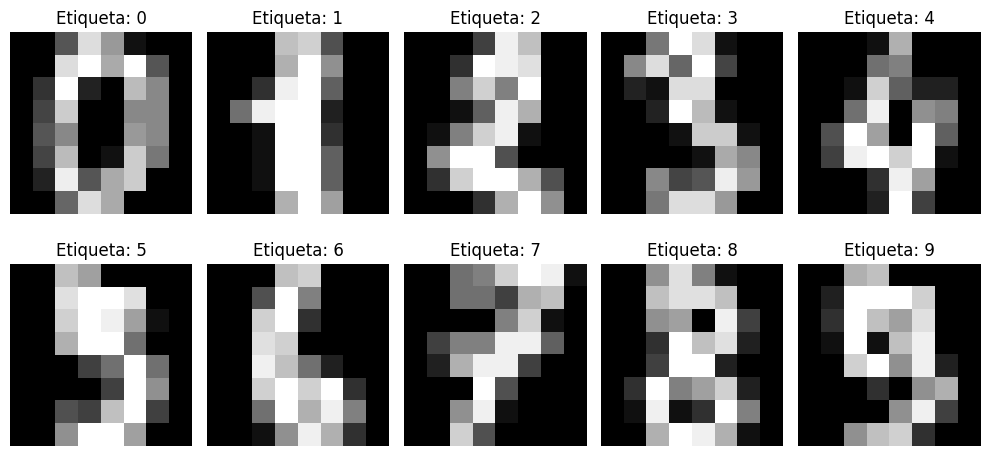

In [77]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"Etiqueta: {digits.target[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# 4. Conversión a clasificación binaria

In [78]:
y_binary = (y_multiclase == 5).astype(int)

print("Cantidad de 5:", np.sum(y_binary == 1))
print("Cantidad de no-5:", np.sum(y_binary == 0))

Cantidad de 5: 182
Cantidad de no-5: 1615


# 5. División de datos

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1437, 64)
Test: (360, 64)


# 6. Entrenamiento del modelo SGDClassifier

SGDClassifier utiliza descenso de gradiente estocástico para entrenar modelos lineales.

In [80]:
sgd_model = SGDClassifier(
    random_state=42
)

sgd_model.fit(X_train, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


# 7. Predicciones

In [132]:
y_pred = sgd_model.predict(X_test)

print(y_pred[:20])

[1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0]


# 8. Accuracy

In [133]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9888888888888889


# 9. Precision

In [134]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 1.0


# 10. Recall

In [135]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.8888888888888888


# 11. F1-Score

In [136]:
f1 = f1_score(y_test, y_pred)

print("F1-score:", f1)

F1-score: 0.9411764705882353


# 12. Reporte completo de clasificación

In [137]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       324
           1       1.00      0.89      0.94        36

    accuracy                           0.99       360
   macro avg       0.99      0.94      0.97       360
weighted avg       0.99      0.99      0.99       360



# 13. Matriz de confusión

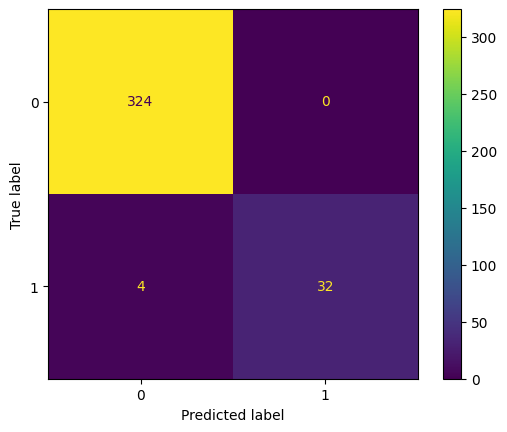

In [138]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

# 14. Curva ROC y AUC

In [139]:
y_scores = sgd_model.decision_function(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

auc_score = roc_auc_score(y_test, y_scores)

print("ROC AUC:", auc_score)

ROC AUC: 0.9993141289437585


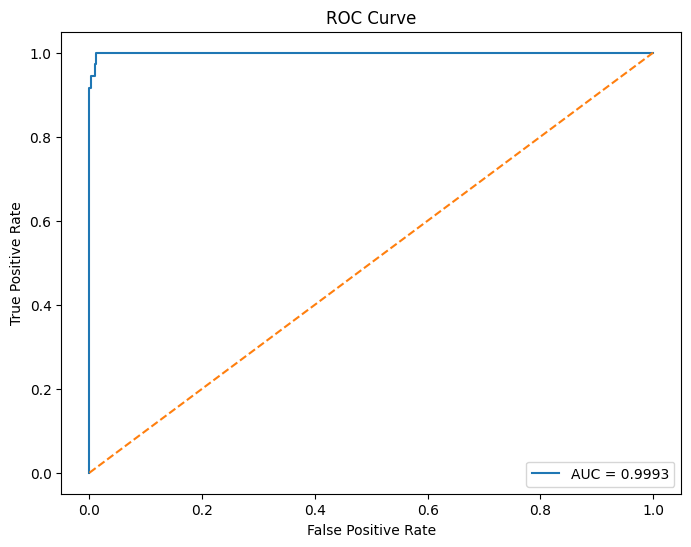

In [140]:
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# 15. Fase 2: Comparación con Random Forest

Entrenaremos un modelo de Random Forest para comparar su rendimiento con el SGDClassifier.

In [141]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)
random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)
scores_rf = random_forest.predict_proba(X_test)[:, 1]


In [142]:
# Mapeo de variables previas del SGD para la comparativa
y_pred_sgd = y_pred
scores_sgd = y_scores
auc_sgd = auc_score
fpr_sgd = fpr
tpr_sgd = tpr

comparacion = pd.DataFrame([
    {
        "modelo": "SGDClassifier",
        "accuracy": accuracy_score(y_test, y_pred_sgd),
        "precision": precision_score(y_test, y_pred_sgd, zero_division=0),
        "recall": recall_score(y_test, y_pred_sgd, zero_division=0),
        "f1": f1_score(y_test, y_pred_sgd, zero_division=0),
        "roc_auc": roc_auc_score(y_test, scores_sgd),
        "average_precision": average_precision_score(y_test, scores_sgd),
    },
    {
        "modelo": "RandomForestClassifier",
        "accuracy": accuracy_score(y_test, y_pred_rf),
        "precision": precision_score(y_test, y_pred_rf, zero_division=0),
        "recall": recall_score(y_test, y_pred_rf, zero_division=0),
        "f1": f1_score(y_test, y_pred_rf, zero_division=0),
        "roc_auc": roc_auc_score(y_test, scores_rf),
        "average_precision": average_precision_score(y_test, scores_rf),
    },
]).set_index("modelo")

display(comparacion.style.format("{:.3f}"))


,accuracy,precision,recall,f1,roc_auc,average_precision
modelo,,,,,,
SGDClassifier,0.989,1.000,0.889,0.941,0.999,0.994
RandomForestClassifier,0.989,1.000,0.889,0.941,1.000,0.998


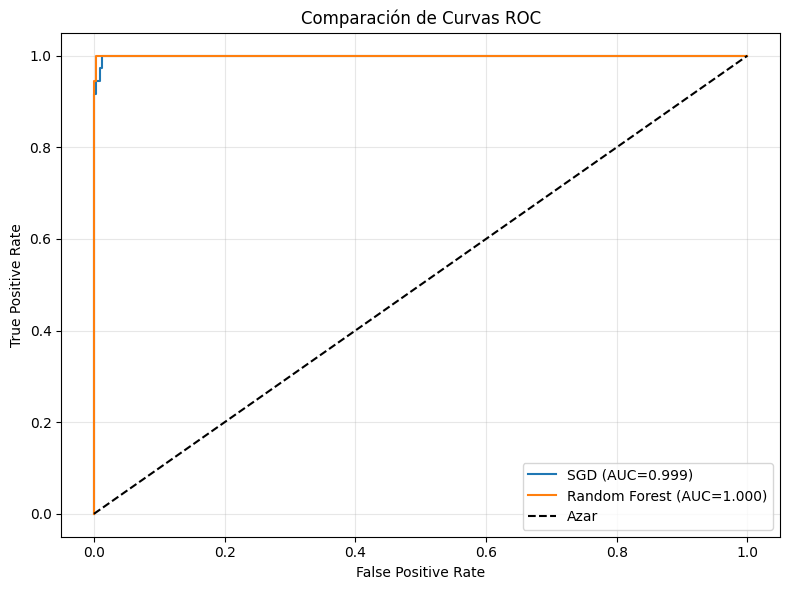

In [143]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, scores_rf)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_sgd, tpr_sgd, label=f"SGD (AUC={auc_sgd:.3f})")
ax.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, scores_rf):.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Azar")
ax.set_title("Comparación de Curvas ROC")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
